### Implementing LQR for the ACS on an OTV

Constraints:
1. Convex Cost

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# import from sim_2.ipynb
class OrbitalTransferVehicle:
    def __init__(self, t_span, z_pay, cntrl_type, m_body = 2000, r_body = 2.5, h_body = 5, m_pay = 500, s_pay = 1, K_p = 20, K_d = 400):
        """
        Initialize the OTV.
        """
        self.delta_t = 0.01
        self.x = np.zeros((6, 1))  # initial conditions for the state vector
        self.t = 0.0
        self.t_span = t_span # final time of simulation

        self.m_body = m_body
        self.r = r_body
        self.h = h_body

        self.m_pay = m_pay  # mass of payload
        self.s_pay = s_pay
        self.x_pay = 0
        self.y_pay = r_body + s_pay / 2 # distance from the center of mass to the payload in y direction
        self.z_pay = z_pay

        self.I = self.set_inertia()

        self.K_p = K_p
        self.K_d = K_d

        controllers = {
            "PD": self.pd_cntrl,
            "LQR": self.lqr_cntrl
        }

        if cntrl_type not in controllers:
            raise ValueError(f"Controller type '{cntrl_type}' is not supported. Choose from {list(controllers.keys())}.")
        
        self.cntrl = controllers[cntrl_type]
    
    def set_inertia(self):
        """
        Set the inertia matrix based on the mass of the payload.
        """
        # Inertia matrix for a cylindrical body
        m = self.m_body
        r = self.r
        h = self.h

        I_cyc = np.array([1/12*m*(3*r**2 + h**2), 1/12*m*(3*r**2 + h**2), 1/2*m*r**2]) # Ixx, Iyy, Izz
        print("Inertia Matrix (Cylindrical Body):", I_cyc)

        m_pay = self.m_pay
        s_pay = self.s_pay  # m, side length of the payload cube
        I_pay = np.array([1/6*m_pay*s_pay**2, 1/6*m_pay*s_pay**2, 1/6*m_pay*s_pay**2])

        # parallel axis theorm, rotate about the satellite body principle axis
        # I = I_cm + m * d^2
        d_x = np.sqrt(self.y_pay**2 + self.z_pay**2)  # distance from the center of mass to the payload in x direction
        d_y = np.sqrt(self.z_pay**2 + self.x_pay**2)  # "                                                " y direction
        d_z = np.sqrt(self.x_pay**2 + self.y_pay**2)  # "                                                " z direction

        I_comp = I_cyc + I_pay + np.array([m_pay*d_x**2, m_pay*d_y**2, m_pay*d_z**2]) # x, y, z adjustment to inertia matrix
        print("Inertia Matrix (Cylindrical Body + Payload):", I_comp)

        return I_comp

    def pd_cntrl(self, x, x_d):
        """
        Compute the control input based on the current state and desired state.
        """
        assert x.shape == (6, 1)
        assert x_d.shape == (6, 1)

        e = x - x_d

        # PD <- PID will need to remember error, bigger state
        u_1 = -1 * (self.K_p * e[0] + self.K_d * e[3])
        u_2 = -1 * (self.K_p * e[1] + self.K_d * e[4])
        u_3 = -1 * (self.K_p * e[2] + self.K_d * e[5])
        u = np.array([[u_1], [u_2], [u_3]])  # control input
        u.resize((3, 1))  # ensure shape is (3, 1)
        assert u.shape == (3, 1)

        return u
    
    def lqr_cntrl(self, x, x_d):
        """ 
        Implementation of Linear Quadratic Regulator (LQR) control.
        """


        u = np.array([[0], [0], [0]])  # Initialize control input

        assert u.shape == (3, 1) # m1, m2, m3
        return u

    def dyn(self, x, u):
        """
        Compute the state derivative based on the current state, inertia, and control input.
        """
        assert x.shape == (6, 1)

        I_1, I_2, I_3 = self.I
        M_1, M_2, M_3 = u

        x_dot = np.zeros((6, 1))  # Initialize the state derivative

        x_dot[0] = x[3]
        x_dot[1] = x[4]
        x_dot[2] = x[5]
        
        # Euler's Rotation Equations
        x_dot[3] = 1/I_1 * (M_1 - (I_3 - I_2) * x[4] * x[5])
        x_dot[4] = 1/I_2 * (M_2 - (I_1 - I_3) * x[5] * x[3])
        x_dot[5] = 1/I_3 * (M_3 - (I_2 - I_1) * x[3] * x[4])

        return x_dot
    
    def sim(self, x_d):
        """
        Simulate the system dynamics over the specified time span.
        """

        while self.t < self.t_span:
            curr_x = self.x[:,-1].reshape(-1, 1)

            # Compute Control Input
            u = self.cntrl(curr_x, x_d)

            # Compute State Derivative
            x_dot = self.dyn(curr_x, u)
            assert x_dot.shape == (6, 1)

            # Simulate the system using Euler Integration
            next_x = curr_x + x_dot * self.delta_t
            self.x = np.hstack((self.x, next_x))
            
            self.t += self.delta_t

        return self.x
    
    def plot(self, ax=None):
        """
        Plot the state variables of the OTV over time.
        """

        if ax is None:
            ax = plt.gca()

        ax.plot(self.x[0, :], label='Roll - x')
        ax.plot(self.x[1, :], label='Pitch - y')
        ax.plot(self.x[2, :], label='Yaw - z')
        #ax.plot(self.x[3, :], label='Omega 1', linestyle='--')
        #ax.plot(self.x[4, :], label='Omega 2', linestyle='--')
        #ax.plot(self.x[5, :], label='Omega 3', linestyle='--')
        plt.title(f'PD Controller Kp={self.K_p}, Kd={self.K_d}')
        plt.hlines(y=np.pi/6, xmin=0, xmax=self.x.shape[1]-1, colors='r', linestyles='dashed', label='Desired Roll (30 degrees)')
        plt.xlabel('Time Steps')
        plt.ylabel('State Values')
        plt.legend()


In [9]:
x_desired = np.array([[np.pi/6], [0], [0], [0], [0], [0]])  # Desired state: Roll = 30 degrees, Pitch = Yaw = 0


otv_pd = OrbitalTransferVehicle(t_span=100, z_pay=0, cntrl_type="PD", m_pay=0)
x_pd = otv_pd.sim(x_desired)

otv_lqr = OrbitalTransferVehicle(t_span=100, z_pay=0, cntrl_type="LQR", m_pay=0)
x_lqr = otv_lqr.sim(x_desired)



Inertia Matrix (Cylindrical Body): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body + Payload): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body): [7291.66666667 7291.66666667 6250.        ]
Inertia Matrix (Cylindrical Body + Payload): [7291.66666667 7291.66666667 6250.        ]


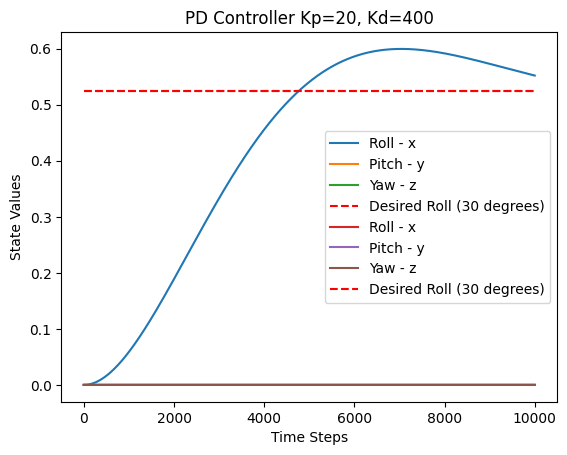

In [12]:
otv_pd.plot()
otv_lqr.plot()
plt.show()

Resources:
1. https://underactuated.mit.edu/lqr.html